# 04 · Survival Analysis: Kaplan–Meier and Cox

Alive patients were followed for different lengths of time, so the outcome is censored. Kaplan–Meier (Kaplan & Meier, 1958) uses each patient for as long as she was observed. The Cox model (Cox, 1972) estimates adjusted hazard ratios. Library: `lifelines`.

In [1]:
import sys, warnings
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import multivariate_logrank_test, proportional_hazard_test
from lifelines.utils import median_survival_times
from lifelines.plotting import add_at_risk_counts

from seer_survival import config as C
from seer_survival.data import load_clean
from seer_survival.plots import set_style, save_fig, PALETTE

set_style()
df = load_clean()
T, E = df[C.TIME_COL], df[C.EVENT_COL]
print(f"patients={len(df)}, events={E.sum()} ({E.mean():.1%}), censored={len(df)-E.sum()}")

patients=4024, events=616 (15.3%), censored=3408


## 1. Overall survival and follow-up

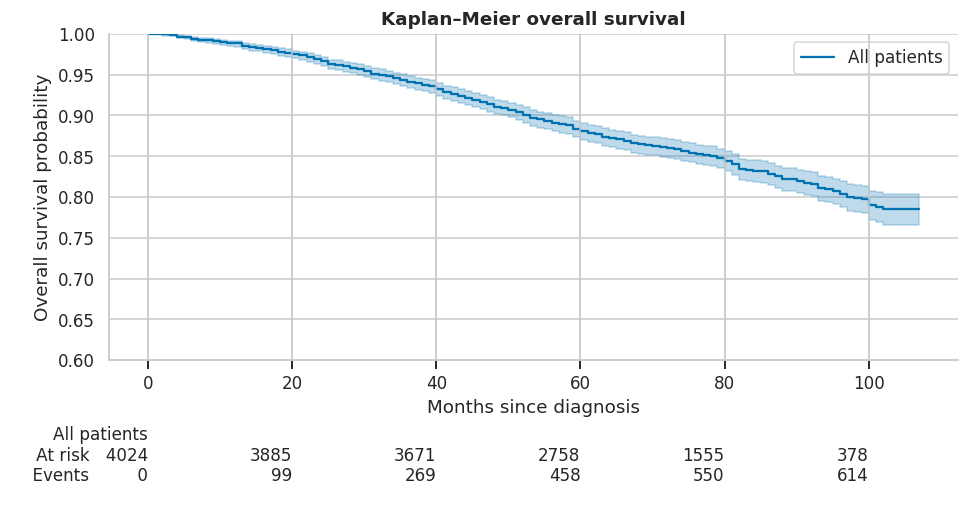

,S(t),95% CI low,95% CI high
36 months,0.941,0.933,0.948
60 months,0.881,0.870,0.891
84 months,0.832,0.818,0.845


In [2]:
kmf = KaplanMeierFitter(label="All patients").fit(T, E)
fig, ax = plt.subplots(figsize=(9, 5))
kmf.plot_survival_function(ax=ax, ci_show=True, color=PALETTE[0])
add_at_risk_counts(kmf, ax=ax, rows_to_show=["At risk", "Events"])
ax.set_xlabel("Months since diagnosis"); ax.set_ylabel("Overall survival probability")
ax.set_ylim(0.6, 1.0); ax.set_title("Kaplan–Meier overall survival")
fig.tight_layout(); save_fig(fig, "04_km_overall"); plt.show()

surv_at = kmf.survival_function_at_times(C.EVAL_TIMES)
ci = kmf.confidence_interval_survival_function_
tab = pd.DataFrame({"S(t)": surv_at.values,
                    "95% CI low": [ci.loc[:t].iloc[-1, 0] for t in C.EVAL_TIMES],
                    "95% CI high": [ci.loc[:t].iloc[-1, 1] for t in C.EVAL_TIMES]},
                   index=[f"{t} months" for t in C.EVAL_TIMES])
tab.round(3)

**Median follow-up (reverse Kaplan–Meier).** The event and censoring indicators are swapped, so the median of this curve is the median *potential* follow-up. This is the standard way to report follow-up (Schemper & Smith, *Control Clin Trials* 1996; 17:343–346).

In [3]:
rkm = KaplanMeierFitter().fit(T, 1 - E)
print(f"Median follow-up (reverse KM): {rkm.median_survival_time_:.0f} months")
print(f"Median survival not reached: min S(t) = {kmf.survival_function_.iloc[-1, 0]:.3f}")

Median follow-up (reverse KM): 78 months
Median survival not reached: min S(t) = 0.786


## 2. How censoring is distributed

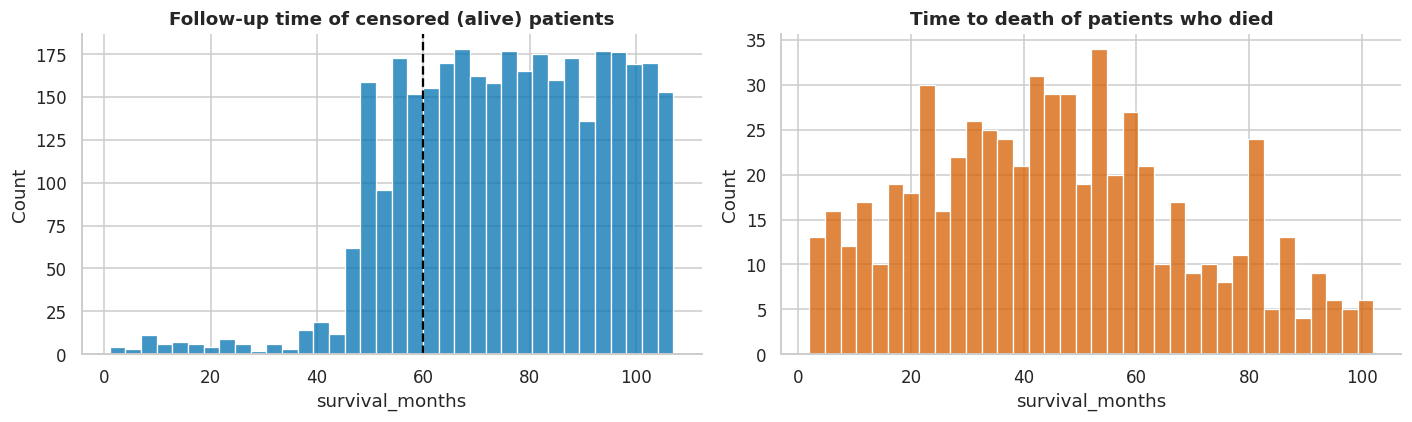

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df[df.event == 0][C.TIME_COL], bins=36, ax=axes[0], color=PALETTE[0])
axes[0].axvline(60, ls="--", c="k"); axes[0].set_title("Follow-up time of censored (alive) patients")
sns.histplot(df[df.event == 1][C.TIME_COL], bins=36, ax=axes[1], color=PALETTE[1])
axes[1].set_title("Time to death of patients who died")
fig.tight_layout(); save_fig(fig, "04_censoring"); plt.show()

Most alive patients have 50–107 months of follow-up, and few have less. This fits administrative censoring: diagnoses from 2006–2010 followed to a common end date. The data source does not state the end date, so this cannot be confirmed. If it holds, censoring is unrelated to prognosis, as Kaplan–Meier and Cox assume.

## 3. Kaplan–Meier by clinical group + log-rank tests

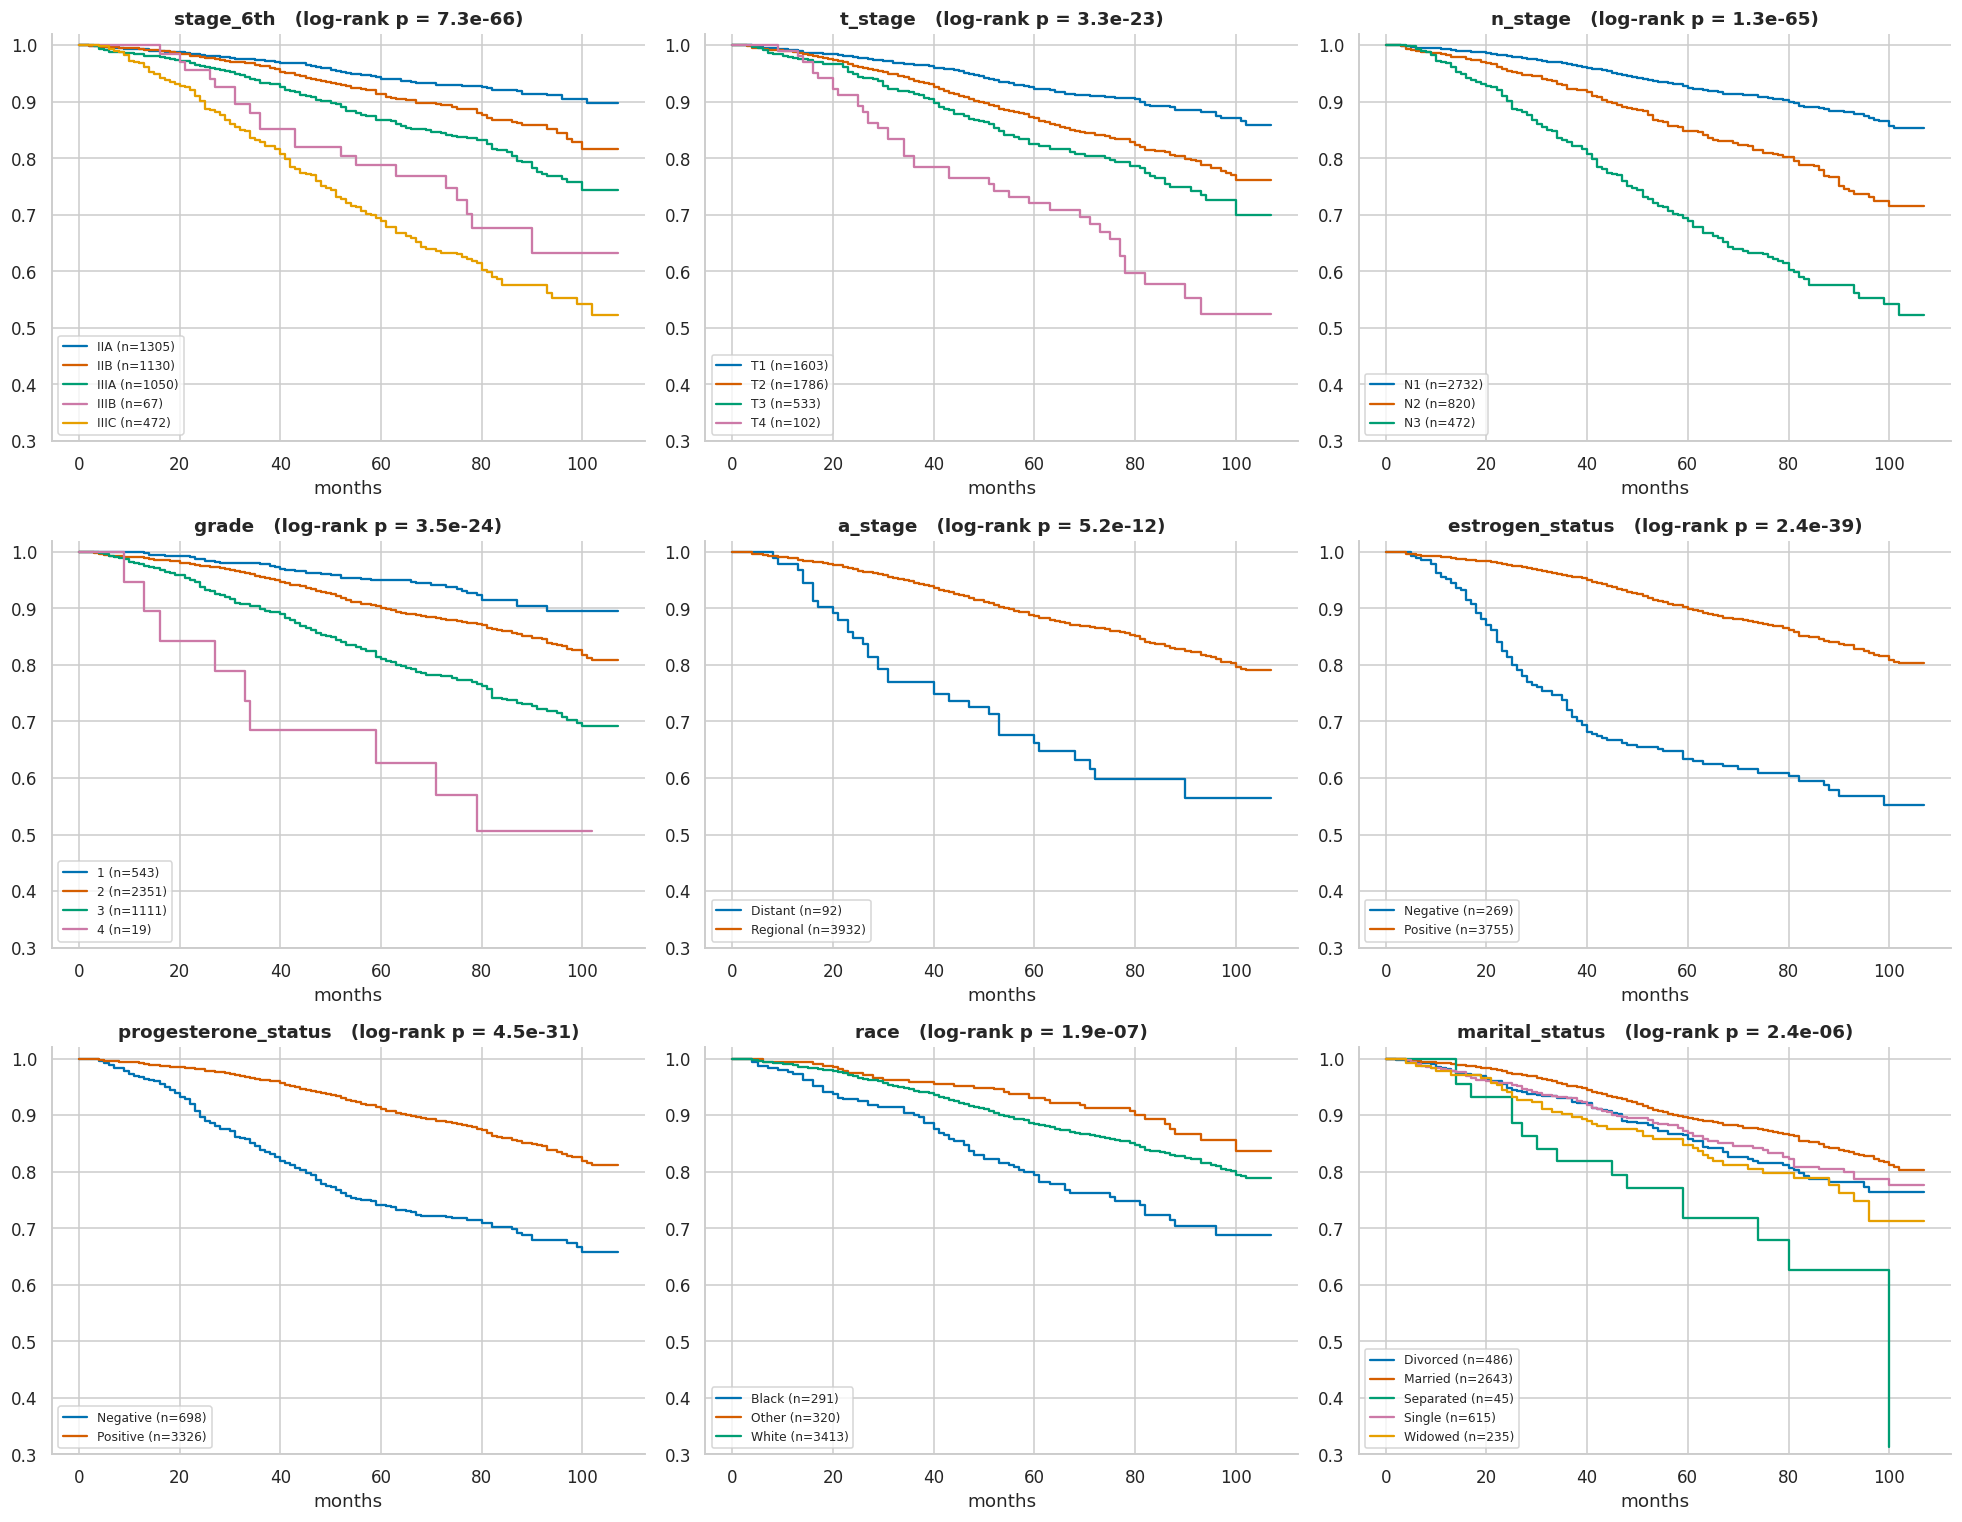

In [5]:
groups = ["stage_6th", "t_stage", "n_stage", "grade", "a_stage", "estrogen_status",
          "progesterone_status", "race", "marital_status"]
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
lr_rows = []
for ax, g in zip(axes.ravel(), groups):
    levels = C.ORDINAL_LEVELS.get(g) or sorted(df[g].unique())
    for i, lv in enumerate(levels):
        m = df[g] == lv
        KaplanMeierFitter(label=f"{lv} (n={m.sum()})").fit(T[m], E[m]).plot_survival_function(
            ax=ax, ci_show=False, color=PALETTE[i % len(PALETTE)])
    res = multivariate_logrank_test(T, df[g], E)
    lr_rows.append({"variable": g, "chi2": res.test_statistic, "df": len(levels) - 1, "p": res.p_value})
    ax.set_title(f"{g}   (log-rank p = {res.p_value:.1e})"); ax.set_xlabel("months"); ax.set_ylim(0.3, 1.02)
    ax.legend(fontsize=8, loc="lower left")
fig.tight_layout(); save_fig(fig, "04_km_by_group"); plt.show()

In [6]:
from statsmodels.stats.multitest import multipletests
lr = pd.DataFrame(lr_rows)
lr["p_adj_BH"] = multipletests(lr.p, method="fdr_bh")[1]
lr.sort_values("chi2", ascending=False).round(4)

,variable,chi2,df,p,p_adj_BH
0,stage_6th,310.0654,4,0.0,0.0
2,n_stage,298.8577,2,0.0,0.0
5,estrogen_status,172.2190,1,0.0,0.0
6,progesterone_status,134.3660,1,0.0,0.0
3,grade,112.2830,3,0.0,0.0
1,t_stage,107.7986,3,0.0,0.0
4,a_stage,47.6249,1,0.0,0.0
8,marital_status,31.5430,4,0.0,0.0
7,race,30.9829,2,0.0,0.0


## 4. Survival at 36 / 60 / 84 months by stage group

In [7]:
rows = []
for lv in C.ORDINAL_LEVELS["stage_6th"]:
    m = df.stage_6th == lv
    k = KaplanMeierFitter().fit(T[m], E[m])
    s = k.survival_function_at_times(C.EVAL_TIMES).values
    rows.append([lv, m.sum(), E[m].sum(), *s])
pd.DataFrame(rows, columns=["stage", "n", "deaths", "S(36)", "S(60)", "S(84)"]).round(3)

,stage,n,deaths,S(36),S(60),S(84)
0,IIA,1305,96,0.973,0.939,0.921
1,IIB,1130,135,0.963,0.913,0.867
2,IIIA,1050,184,0.934,0.867,0.814
3,IIIB,67,20,0.851,0.787,0.677
4,IIIC,472,181,0.829,0.689,0.576


## 5. Kaplan–Meier by lymph-node-ratio tertile (preview for H3)

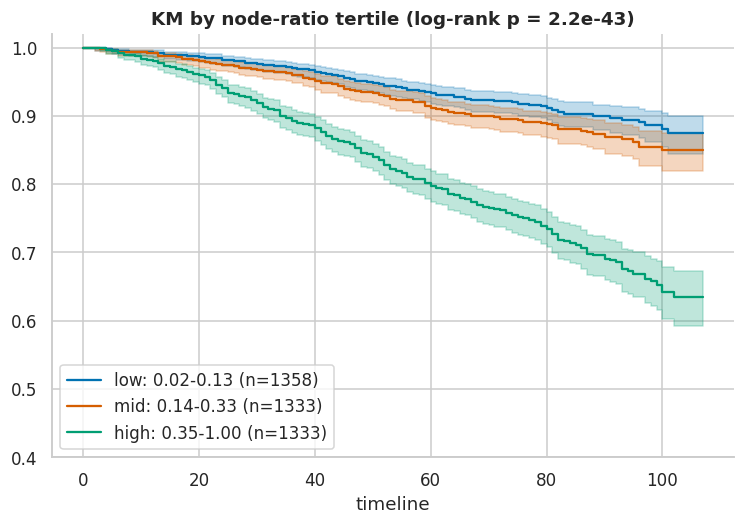

In [8]:
df["node_ratio"] = df.nodes_positive / df.nodes_examined
df["lnr_tertile"] = pd.qcut(df.node_ratio, 3, labels=["low", "mid", "high"])
fig, ax = plt.subplots(figsize=(8, 5))
for i, lv in enumerate(["low", "mid", "high"]):
    m = df.lnr_tertile == lv
    rng = df.loc[m, "node_ratio"]
    KaplanMeierFitter(label=f"{lv}: {rng.min():.2f}-{rng.max():.2f} (n={m.sum()})").fit(T[m], E[m]) \
        .plot_survival_function(ax=ax, color=PALETTE[i])
res = multivariate_logrank_test(T, df.lnr_tertile, E)
ax.set_title(f"KM by node-ratio tertile (log-rank p = {res.p_value:.1e})"); ax.set_ylim(0.4, 1.02)
save_fig(fig, "04_km_lnr"); plt.show()

## 6. Multivariable Cox model (descriptive, whole cohort)

Descriptive model on the full cohort: adjusted effect sizes. Predictive performance is measured on held-out data in notebook 07.

In [9]:
cox_df = df[["age", "tumor_size", "nodes_examined", "nodes_positive", "grade", "survival_months", "event"]].copy()
cox_df["log_tumor_size"] = np.log1p(cox_df.pop("tumor_size"))
cox_df["log_nodes_positive"] = np.log1p(cox_df.pop("nodes_positive"))
cox_df["age_per10"] = cox_df.pop("age") / 10
for c, ref in [("t_stage", "T1"), ("n_stage", "N1"), ("race", "White"), ("marital_status", "Married")]:
    d = pd.get_dummies(df[c], prefix=c, dtype=int).drop(columns=f"{c}_{ref}")
    cox_df = cox_df.join(d)
cox_df["er_negative"] = (df.estrogen_status == "Negative").astype(int)
cox_df["pr_negative"] = (df.progesterone_status == "Negative").astype(int)
cox_df["distant_a_stage"] = (df.a_stage == "Distant").astype(int)

cph = CoxPHFitter(penalizer=0.0).fit(cox_df, duration_col="survival_months", event_col="event")
summ = cph.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]]
summ.columns = ["HR", "HR low", "HR high", "p"]
print(f"Apparent (in-sample) concordance: {cph.concordance_index_:.3f}  <- optimistic, see notebook 07")
summ.sort_values("HR", ascending=False).round(3)

Apparent (in-sample) concordance: 0.744  <- optimistic, see notebook 07


,HR,HR low,HR high,p
covariate,,,,
t_stage_T4,2.086,1.273,3.418,0.004
marital_status_Separated,2.043,1.204,3.466,0.008
er_negative,1.962,1.507,2.556,0.000
log_nodes_positive,1.771,1.388,2.261,0.000
pr_negative,1.601,1.299,1.973,0.000
grade,1.471,1.286,1.682,0.000
race_Black,1.451,1.127,1.868,0.004
n_stage_N3,1.448,0.930,2.254,0.102
t_stage_T3,1.413,0.890,2.244,0.142


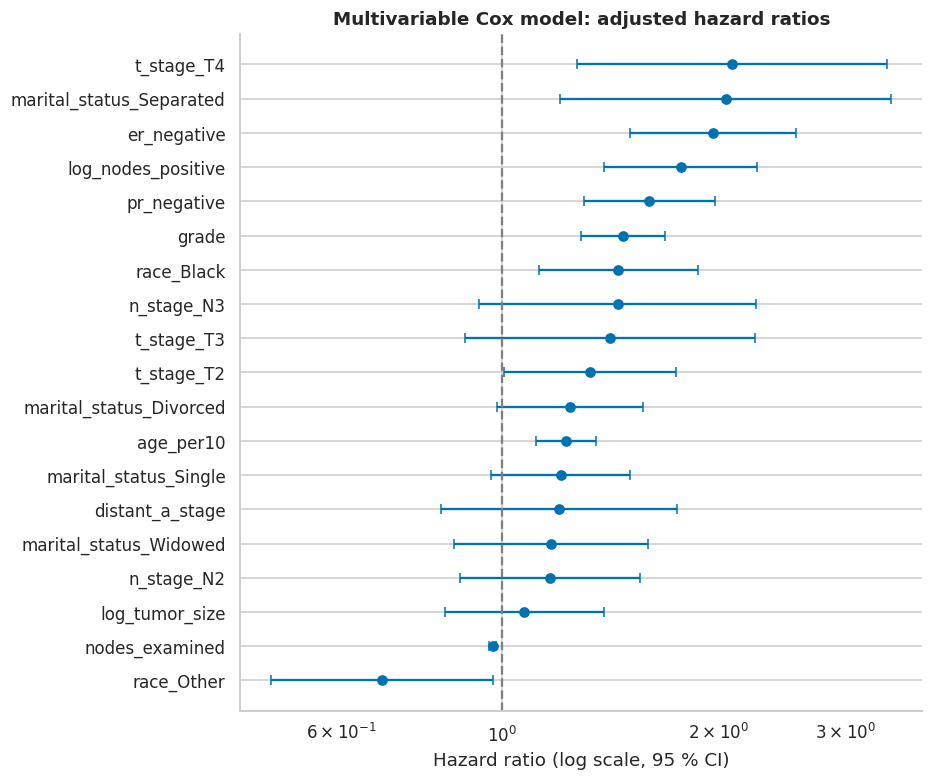

In [10]:
fig, ax = plt.subplots(figsize=(8, 8))
s = summ.sort_values("HR")
ax.errorbar(s.HR, range(len(s)), xerr=[s.HR - s["HR low"], s["HR high"] - s.HR], fmt="o", c=PALETTE[0], capsize=3)
ax.axvline(1, c="grey", ls="--"); ax.set_xscale("log")
ax.set_yticks(range(len(s)), s.index); ax.set_xlabel("Hazard ratio (log scale, 95 % CI)")
ax.set_title("Multivariable Cox model: adjusted hazard ratios")
save_fig(fig, "04_cox_forest"); plt.show()

## 7. Checking the proportional-hazards assumption

Scaled Schoenfeld residual test (Grambsch & Therneau, *Biometrika* 1994; 81:515–526). A small p-value means the effect of that variable changes over time.

In [11]:
ph = proportional_hazard_test(cph, cox_df, time_transform="rank")
ph_tab = ph.summary[["test_statistic", "p"]].sort_values("p")
ph_tab["p_adj_BH"] = multipletests(ph_tab.p, method="fdr_bh")[1]
ph_tab.round(4)

,test_statistic,p,p_adj_BH
er_negative,9.5423,0.0020,0.0202
pr_negative,9.4395,0.0021,0.0202
distant_a_stage,6.5703,0.0104,0.0657
log_tumor_size,3.4111,0.0648,0.3076
t_stage_T4,2.8821,0.0896,0.3404
t_stage_T2,2.3571,0.1247,0.3949
t_stage_T3,2.0482,0.1524,0.4136
log_nodes_positive,1.7113,0.1908,0.4532
marital_status_Single,1.3686,0.2421,0.5110
n_stage_N3,0.9311,0.3346,0.6357


## 8. Where does the PH assumption fail, visually?

Variables with evidence of non-proportional hazards (BH 5 %): ['er_negative', 'pr_negative']


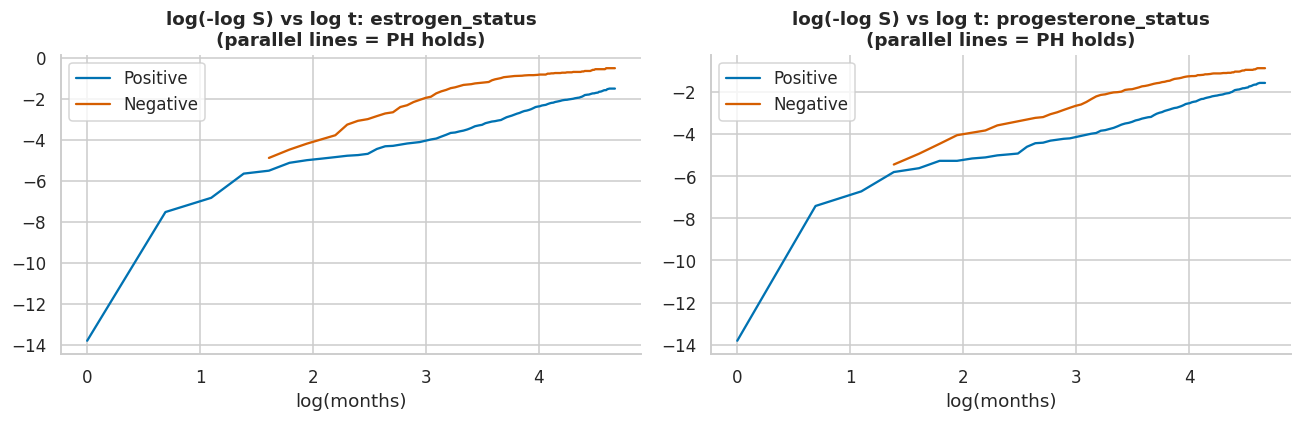

In [12]:
viol = ph_tab.index[ph_tab.p_adj_BH < 0.05].tolist()
print("Variables with evidence of non-proportional hazards (BH 5 %):", viol or "none")
show = viol[:3] if viol else ["er_negative"]
fig, axes = plt.subplots(1, len(show), figsize=(6 * len(show), 4), squeeze=False)
for ax, var in zip(axes[0], show):
    if var in ("er_negative", "pr_negative"):
        col = "estrogen_status" if var == "er_negative" else "progesterone_status"
        for i, lv in enumerate(["Positive", "Negative"]):
            m = df[col] == lv
            k = KaplanMeierFitter().fit(T[m], E[m])
            sf = k.survival_function_.iloc[:, 0].clip(1e-6, 0.999999)
            ax.plot(np.log(sf.index[sf.index > 0]), np.log(-np.log(sf[sf.index > 0])), label=lv, c=PALETTE[i])
        ax.set_title(f"log(-log S) vs log t: {col}\n(parallel lines = PH holds)")
        ax.set_xlabel("log(months)"); ax.legend()
    else:
        ax.text(0.5, 0.5, f"see test table for {var}", ha="center"); ax.axis("off")
fig.tight_layout(); save_fig(fig, "04_ph_check"); plt.show()

## 9. Sensitivity check: stratify on ER/PR

ER and PR fail the proportional-hazards test. Stratifying on them gives each group its own baseline hazard. If the other hazard ratios barely change, the violation does not affect them.

In [13]:
cph_strat = CoxPHFitter().fit(cox_df, duration_col="survival_months", event_col="event",
                              strata=["er_negative", "pr_negative"])
cmp = pd.DataFrame({"HR (unstratified)": cph.hazard_ratios_, "HR (stratified by ER/PR)": cph_strat.hazard_ratios_}).dropna()
cmp["relative change %"] = (cmp.iloc[:, 1] / cmp.iloc[:, 0] - 1) * 100
print("max |relative change| in HR:", f"{cmp['relative change %'].abs().max():.1f} %")
cmp.round(3)

max |relative change| in HR: 8.0 %


,HR (unstratified),HR (stratified by ER/PR),relative change %
covariate,,,
age_per10,1.229,1.225,-0.290
distant_a_stage,1.200,1.167,-2.724
grade,1.471,1.469,-0.128
log_nodes_positive,1.771,1.763,-0.456
log_tumor_size,1.074,1.062,-1.095
marital_status_Divorced,1.243,1.224,-1.541
marital_status_Separated,2.043,1.879,-8.044
marital_status_Single,1.207,1.192,-1.195
marital_status_Widowed,1.171,1.148,-1.960


## Findings

- Overall survival: 94.1 % at 3 years, 88.1 % at 5 years, 83.2 % at 7 years. Median follow-up is 78 months.
- 5-year survival falls from 93.9 % (stage IIA) to 68.9 % (IIIC).
- Nodal burden, ER/PR-negative status, grade, T4, age and Black race are independent adverse factors in the Cox model. These are adjusted associations, not causal effects.
- At the same positive-node count, more nodes examined means lower hazard (HR 0.971 per node).
- ER and PR violate proportional hazards (adjusted p = 0.020), so their HRs are averages over time.
- Stratifying on ER/PR changes the other HRs by less than 3 %, except `Separated` (8 %, n = 45).
- The in-sample C-index of 0.744 is optimistic. Held-out estimates are in notebook 07, which also compares models that do not assume proportional hazards.